# Solving the context overflow problem using Trimming
- It trims the past messages before sending it as a context to the LLM
- We use `trim_messages` from langchain

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages, count_tokens_approximately
from langgraph.checkpoint.memory import InMemorySaver


/Users/ritumalage/Documents/my_github/Notes/.venv_langgraph/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = ChatGroq(model = "qwen/qwen3-32b") 

# Defining the max tokens
- If the no of tokens passed as an input context is > MAX_TOKENS then trimming will be performed

In [3]:
MAX_TOKENS = 150

# Defining the function
- Even before the past conversations is passed to the LLM, first we call the `trim_messages` function and then passed the trimmed output to the LLM to avoid context overflow
- In the state still the full history is stored
- To the LLM only trimmed information is passed

In [4]:
def call_model(state: MessagesState):

    print(f"Token count before trimming: {count_tokens_approximately(messages=state["messages"])}")
    
    trimmed_messages = trim_messages(
        state["messages"],
        strategy="last", # Only last N tokens will be considered
        token_counter=count_tokens_approximately, # Counts the no of tokens
        max_tokens=MAX_TOKENS # Max no of tokens that can exist
    )
    
    print(f"Token count after trimming: {count_tokens_approximately(messages=trimmed_messages)}")
    response = model.invoke(trimmed_messages)
    
    return {"messages": [response]}

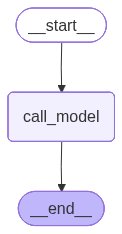

In [5]:
graph = StateGraph(MessagesState)

graph.add_node("call_model", call_model)
graph.add_edge(START, "call_model")


checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [6]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}

response = workflow.invoke(
    {"messages": HumanMessage(content="Hi my name is John")}, 
    config
)
response["messages"][-1].content

Token count before trimming: 9
Token count after trimming: 9


'<think>\nOkay, the user introduced himself as John. First, I should respond in a friendly and welcoming manner. I need to acknowledge his name and ask how I can assist him to keep the conversation going. The response should be concise, avoiding complex sentences. At the same time, I should maintain a natural and warm tone, not too formal. I should check if there are any special requirements, but since there are none, just follow the basic guidelines. Let me make sure the response is in English and meets all the requirements.\n</think>\n\nHello John! Nice to meet you. How can I assist you today? 😊'

# Continuing the conversation

In [7]:

response = workflow.invoke(
    {"messages": HumanMessage(content="I am learning LangGraph, so can you explain me what is LangGraph, and why is it used?")}, 
    config
)
response

Token count before trimming: 190
Token count after trimming: 26


{'messages': [HumanMessage(content='Hi my name is John', additional_kwargs={}, response_metadata={}, id='6984fc7d-7902-4de2-937c-00ac1d502bcd'),
  AIMessage(content='<think>\nOkay, the user introduced himself as John. First, I should respond in a friendly and welcoming manner. I need to acknowledge his name and ask how I can assist him to keep the conversation going. The response should be concise, avoiding complex sentences. At the same time, I should maintain a natural and warm tone, not too formal. I should check if there are any special requirements, but since there are none, just follow the basic guidelines. Let me make sure the response is in English and meets all the requirements.\n</think>\n\nHello John! Nice to meet you. How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 127, 'prompt_tokens': 13, 'total_tokens': 140, 'completion_time': 0.278997809, 'completion_tokens_details': None, 'prompt_time': 0.000353724, 'prompt_

In [8]:

response = workflow.invoke(
    {"messages": HumanMessage(content="Hi now can you tell me what is my name again?")}, 
    config
)
response["messages"][-1].content

Token count before trimming: 2464
Token count after trimming: 16


'<think>\nOkay, the user is asking for their name again. Let me check the conversation history. Hmm, the user mentioned "Hi now can you tell me what is my name again?" but I don\'t see any previous messages where they provided their name.\n\nWait, maybe they forgot to mention their name in earlier messages. But looking at the history, the first message is their current question. They haven\'t given their name before. \n\nI need to respond politely. Since I don\'t have their name, I should inform them that I don\'t know it and ask them to provide it. I should make sure to be helpful and not assume any information they haven\'t given. Let me phrase it in a friendly way to encourage them to share their name so I can address them properly in future interactions.\n</think>\n\nI don\'t have access to personal information about users unless you share it with me directly. Could you please tell me your name? I\'d be happy to address you by name in future conversations if you\'d like!'

- Since only last N messages were passed as context to LLM, the starting messages were ignored, and there is where the user has mentioned their name, since that was not being passed the LLM does not have the answer for the same
- This is the issue with triming